<a href="https://colab.research.google.com/github/Sameemudeen/newcode1/blob/main/tesla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd

tesla_data = yf.download('TSLA', start='2020-01-01', end='2023-12-31')

tesla_data.reset_index(inplace=True)

print(tesla_data.head().to_string(index=False, header=False))
tesla_data_head


/tmp/ipython-input-7-4276554294.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla_data = yf.download('TSLA', start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed

2020-01-02 28.684000 28.713333 28.114000 28.299999 142981500
2020-01-03 29.534000 30.266666 29.128000 29.366667 266677500
2020-01-06 30.102667 30.104000 29.333332 29.364668 151995000
2020-01-07 31.270666 31.441999 30.224001 30.760000 268231500
2020-01-08 32.809334 33.232666 31.215334 31.580000 467164500


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
1,2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2,2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
3,2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
4,2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

driver = webdriver.Chrome()


url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
driver.get(url)


time.sleep(5)


tables = driver.find_elements(By.TAG_NAME, "table")
for table in tables:
    if "Tesla Quarterly Revenue" in table.text:
        html = table.get_attribute("outerHTML")
        break

driver.quit()

tesla_revenue = pd.read_html(html)[0]
tesla_revenue.columns = ['Date', 'Revenue']
tesla_revenue['Revenue'] = tesla_revenue['Revenue'].replace({'\$': '', ',': ''}, regex=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != '']
tesla_revenue.dropna(inplace=True)

print(tesla_revenue.tail())


           Date Revenue
18  2023-05-31  24318.0

19  2023-12-30  23329.0

20  2024-03-31  24827.0

21  2024-10-31  23450.0

22  2025-01-31  25100.0


In [ ]:
import yfinance as yf
import pandas as pd

gme_data = yf.download('GME', start='2020-01-01', end='2023-12-31')

gme_data.reset_index(inplace=True)

print(gme_data.head())
gme_data.head()


/tmp/ipython-input-12-1344277803.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gme_data = yf.download('GME', start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed

Price        Date   Close    High     Low    Open    Volume
Ticker                GME     GME     GME     GME       GME
0      2020-01-02  1.5775  1.6175  1.5175  1.5350  17814400
1      2020-01-03  1.4700  1.5625  1.4600  1.5525  14175600
2      2020-01-06  1.4625  1.4775  1.4000  1.4500  13579200
3      2020-01-07  1.3800  1.4575  1.3600  1.4425  20912000
4      2020-01-08  1.4300  1.4625  1.3525  1.3725  22517600


Price,Date,Close,High,Low,Open,Volume
Ticker,,GME,GME,GME,GME,GME
0,2020-01-02,1.5775,1.6175,1.5175,1.5350,17814400
1,2020-01-03,1.4700,1.5625,1.4600,1.5525,14175600
2,2020-01-06,1.4625,1.4775,1.4000,1.4500,13579200
3,2020-01-07,1.3800,1.4575,1.3600,1.4425,20912000
4,2020-01-08,1.4300,1.4625,1.3525,1.3725,22517600


In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import pandas as pd
import time

chrome_options = Options()
chrome_options.add_argument("--no-sandbox")
chrome_options.add_argument("--disable-dev-shm-usage")
chrome_options.add_argument("--headless")
chrome_options.add_argument("--user-data-dir=/tmp/selenium-profile")

driver = webdriver.Chrome(options=chrome_options)

url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
driver.get(url)
time.sleep(5)


tables = driver.find_elements(By.TAG_NAME, "table")
html = None
for table in tables:
    if "GameStop Quarterly Revenue" in table.text:
        html = table.get_attribute("outerHTML")
        break

driver.quit()

if html is not None:
    gme_revenue = pd.read_html(html)[0]
    gme_revenue.columns = ['Date', 'Revenue']
    gme_revenue['Revenue'] = gme_revenue['Revenue'].replace({'\$': '', ',': ''}, regex=True)
    gme_revenue = gme_revenue[gme_revenue['Revenue'] != '']
    gme_revenue.dropna(inplace=True)

    print(gme_revenue.tail())
else:
    print("GameStop Quarterly Revenue table not found.")

GameStop Quarterly Revenue table not found.


          Date Revenue
18  2023-05-31   2252

19  2023-12-30   2045

20  2024-03-31   1871

21  2024-10-31   1790

22  2025-01-31   2144


/tmp/ipython-input-16-1919816378.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla_data = yf.download('TSLA', start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


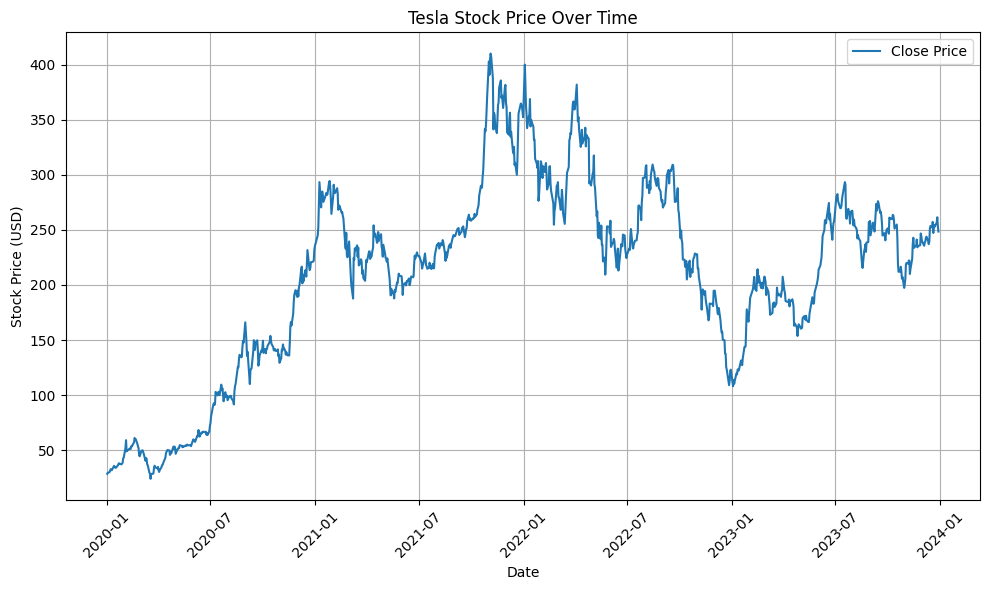

In [ ]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

tesla_data = yf.download('TSLA', start='2020-01-01', end='2023-12-31')
tesla_data.reset_index(inplace=True)

def make_graph(data, title):
    plt.figure(figsize=(10, 6))
    plt.plot(data['Date'], data['Close'], label='Close Price')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Stock Price (USD)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

make_graph(tesla_data, "Tesla Stock Price Over Time")


/tmp/ipython-input-1-3685682935.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gme_data = yf.download('GME', start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


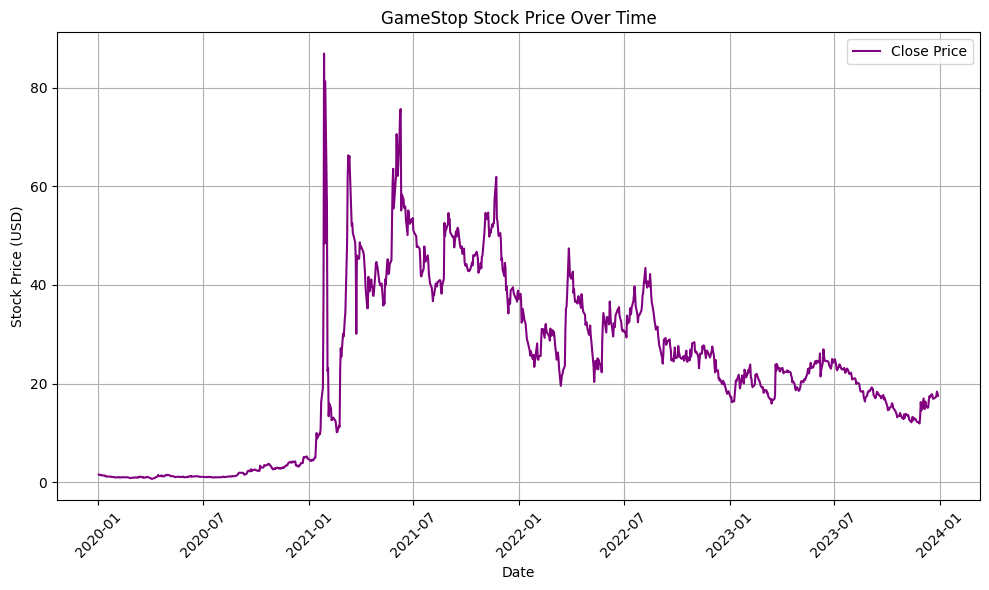

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Download GameStop stock data
gme_data = yf.download('GME', start='2020-01-01', end='2023-12-31')
gme_data.reset_index(inplace=True)

# Step 2: Define the make_graph function (if not already defined)
def make_graph(data, title):
    plt.figure(figsize=(10, 6))
    plt.plot(data['Date'], data['Close'], label='Close Price', color='purple')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Stock Price (USD)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Step 3: Use the function to plot GME stock
make_graph(gme_data, "GameStop Stock Price Over Time")
